# Principal Component Analysis from Scratch

Principal component analysis finds the $k$-dimensional linear subspace that a dataset is closest to, and an
orthogonal coordinate system on it ordered by how much of the data's variance each axis carries. It is fitted
once, in closed form, from a single eigendecomposition or singular value decomposition; there is no iteration,
no random initialisation, and no local optimum to worry about.

There are two ways to say what it is looking for, and this notebook derives both:

- **maximum variance** — find the unit direction $\mathbf{w}$ along which the projected data $\mathbf{w}^\top\mathbf{x}$
  varies most, then the next such direction orthogonal to it, and so on;
- **best rank-$k$ reconstruction** — find the $k$-dimensional affine subspace minimising the total squared
  distance from the data to it.

These sound like different questions. They have the same answer, for a reason that falls out of one line of
algebra, and both are checked numerically below against the same eigenvectors.

This is the first of three notebooks in this folder, and the three solve genuinely different problems:

- **PCA** (here) produces *uncorrelated* directions ordered by variance. It is a linear map, so it applies to
  data it never saw, and it can be inverted onto its subspace to reconstruct.
- **ICA** (`ica.ipynb`) produces *statistically independent* directions. Uncorrelated is a statement about
  second moments only; independent is a statement about the whole joint distribution, and the two are the same
  thing only for Gaussian data. ICA cannot order its components at all, and it does not reduce the dimension —
  it rotates inside the subspace PCA already found.
- **t-SNE** (`tsne.ipynb`) produces a two-dimensional picture in which near neighbours stay near. It is
  non-linear, it is fitted by gradient descent from a random start, and it is not a transform: there is no
  matrix to apply to a new point.

The data is the UCI handwritten digits, 5,620 images of 8x8 pixels, the same dataset used by
`neural_networks/autoencoder.ipynb`, `neural_networks/2d_cnn.ipynb` and `neural_networks/mlp.ipynb`. It suits
PCA because 64 pixels of an 8x8 digit are heavily redundant — neighbouring pixels are lit together, and the
corners are almost never lit at all — so a large fraction of the variance really does live in a few directions,
and because each direction is itself an image and can be drawn.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import style
from ucimlrepo import fetch_ucirepo

style.use('ggplot')

SEED = 0
np.random.seed(SEED)

COLOURS = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#4a3aa7']
blue, orange, green, gold, purple = COLOURS

notebook_start = time.time()
print('numpy', np.__version__)

numpy 2.4.6


## The data

`fetch_ucirepo(id=80)` downloads 5,620 handwritten digits, each a row of 64 numbers holding an 8x8 image
flattened out with pixel values from 0 to 16. Dividing by 16 puts every feature in $[0, 1]$, so a squared error
summed over the 64 pixels is a sum of comparable terms.

The shuffle uses seed 0 and the split is 80/20, identical to `neural_networks/autoencoder.ipynb`. That is
deliberate: the reconstruction errors printed later in this notebook are the same numbers that notebook
compares its linear autoencoder against, and they have to be produced from the same rows to be comparable.

The labels are loaded but take no part in fitting. They are used at the end to colour a scatter plot and to
score how much class structure survives the projection.

In [2]:
digits = fetch_ucirepo(id=80)

X_all = digits.data.features.values.astype(float) / 16.0
y_all = digits.data.targets.values.ravel()

rng = np.random.default_rng(0)
order = rng.permutation(len(X_all))
split = int(0.8 * len(X_all))

train_idx, test_idx = order[:split], order[split:]
X_train, y_train = X_all[train_idx], y_all[train_idx]
X_test, y_test = X_all[test_idx], y_all[test_idx]

N, D = X_train.shape

print('all data:', X_all.shape, ' pixel range', X_all.min(), 'to', X_all.max())
print('train:', X_train.shape, '  test:', X_test.shape)
print('class counts:', np.bincount(y_all))
print()
print('pixels with zero variance in the training set:', np.where(X_train.var(axis=0) == 0)[0])
print('total variance summed over the 64 pixels: %.4f' % X_train.var(axis=0, ddof=1).sum())

all data: (5620, 64)  pixel range 0.0 to 1.0
train: (4496, 64)   test: (1124, 64)
class counts: [554 571 557 572 568 558 558 566 554 562]

pixels with zero variance in the training set: [ 0 39]
total variance summed over the 64 pixels: 4.7002


Two of the 64 pixels — the first pixel of the first row and the last pixel of the fifth — are zero in every
training image. They carry no variance, so no principal component can ever point along them, and the covariance
matrix is singular before anything is fitted. That is worth noticing now because it comes back twice: once when
the eigenvalue spectrum is examined, and once when the eigendecomposition and the SVD are compared on how well
they represent directions with almost no variance.

The figure below shows ten training digits, the mean image, and the per-pixel variance. The variance map is
already an argument for PCA: it is not flat. The ink concentrates in a ring away from the border, and the
border pixels barely move.

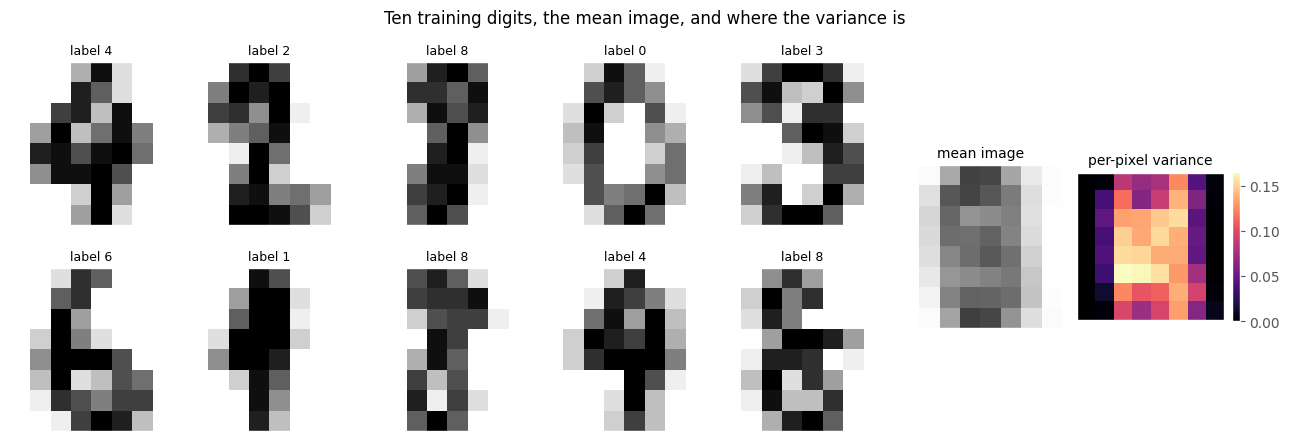

In [3]:
fig = plt.figure(figsize=(13, 4.6))

for i in range(10):
    a = fig.add_subplot(2, 7, (i // 5) * 7 + (i % 5) + 1)
    a.imshow(X_train[i].reshape(8, 8), cmap='gray_r', vmin=0, vmax=1)
    a.set_title('label %d' % y_train[i], fontsize=9)
    a.set_xticks([]); a.set_yticks([]); a.grid(False)

a = fig.add_subplot(1, 7, 6)
a.imshow(X_train.mean(axis=0).reshape(8, 8), cmap='gray_r', vmin=0, vmax=1)
a.set_title('mean image', fontsize=10)
a.set_xticks([]); a.set_yticks([]); a.grid(False)

a = fig.add_subplot(1, 7, 7)
im = a.imshow(X_train.var(axis=0).reshape(8, 8), cmap='magma')
a.set_title('per-pixel variance', fontsize=10)
a.set_xticks([]); a.set_yticks([]); a.grid(False)
fig.colorbar(im, ax=a, fraction=0.046)

plt.suptitle('Ten training digits, the mean image, and where the variance is')
plt.tight_layout()
plt.show()

## Centring, and why it is mandatory

Every derivation below starts by subtracting the mean,

$$\bar{\mathbf{x}} = \frac{1}{N}\sum_{i=1}^{N}\mathbf{x}_i, \qquad
\tilde{\mathbf{x}}_i = \mathbf{x}_i - \bar{\mathbf{x}}.$$

This is not a convenience. Both formulations of PCA are wrong without it.

**From the variance side.** The quantity being maximised is the variance of the projection,

$$\operatorname{Var}(\mathbf{w}^\top\mathbf{x}) = \frac{1}{N}\sum_i \left(\mathbf{w}^\top\mathbf{x}_i - \mathbf{w}^\top\bar{\mathbf{x}}\right)^2
= \mathbf{w}^\top \Sigma \mathbf{w},$$

and that identity only holds when $\Sigma$ is the covariance, $\frac{1}{N}\sum_i \tilde{\mathbf{x}}_i\tilde{\mathbf{x}}_i^\top$.
If the mean is left in, the matrix formed is the second moment $\frac{1}{N}\sum_i \mathbf{x}_i\mathbf{x}_i^\top
= \Sigma + \bar{\mathbf{x}}\bar{\mathbf{x}}^\top$, and maximising $\mathbf{w}^\top(\Sigma + \bar{\mathbf{x}}\bar{\mathbf{x}}^\top)\mathbf{w}$
maximises $\mathbf{w}^\top\Sigma\mathbf{w} + (\mathbf{w}^\top\bar{\mathbf{x}})^2$. The second term rewards
pointing at the mean, which says nothing whatever about how the data varies.

**From the reconstruction side.** The subspace being fitted is affine: a point $\mathbf{b}$ plus a span. Fixing
an orthonormal $V \in \mathbb{R}^{D\times k}$ and minimising

$$J(\mathbf{b}) = \sum_i \big\lVert \mathbf{x}_i - \mathbf{b} - VV^\top(\mathbf{x}_i - \mathbf{b}) \big\rVert^2
= \sum_i \big\lVert (I - VV^\top)(\mathbf{x}_i - \mathbf{b}) \big\rVert^2$$

over $\mathbf{b}$, write $P = I - VV^\top$, which is a projection so $P^\top P = P$. Then
$\partial J/\partial \mathbf{b} = -2P\sum_i(\mathbf{x}_i - \mathbf{b}) = \mathbf{0}$ whenever
$\mathbf{b} = \bar{\mathbf{x}}$. The optimal subspace passes through the mean, whatever $V$ is. Forcing it
through the origin instead — which is what skipping the centring does — is an extra constraint that costs
reconstruction error.

The cell below measures both effects on the digits. It computes the leading direction of the uncentred second
moment matrix and reports the angle between it and the mean image, then compares reconstruction error with and
without centring at several $k$.

In [4]:
mean_image = X_train.mean(axis=0)
X_centred = X_train - mean_image

# leading direction of the uncentred data
_, S_unc, Vt_unc = np.linalg.svd(X_train, full_matrices=False)
V_unc = Vt_unc.T

mean_dir = mean_image / np.linalg.norm(mean_image)
angle_to_mean = np.degrees(np.arccos(abs(V_unc[:, 0] @ mean_dir)))

# leading direction of the centred data
_, S_cen, Vt_cen = np.linalg.svd(X_centred, full_matrices=False)
V_cen = Vt_cen.T


def recon_error(X, V, k, centre):
    # mean squared distance per image between X and its rank-k reconstruction
    Vk = V[:, :k]
    if centre is None:
        R = X @ Vk @ Vk.T
    else:
        R = centre + (X - centre) @ Vk @ Vk.T
    return np.mean(np.sum((X - R) ** 2, axis=1))


print('angle between the leading uncentred direction and the mean image: %.3f degrees' % angle_to_mean)
print('share of the uncentred spectrum in that one direction: %.4f' % (S_unc[0] ** 2 / (S_unc ** 2).sum()))
print('share of the centred spectrum in its leading direction:  %.4f' % (S_cen[0] ** 2 / (S_cen ** 2).sum()))
print()
print('%4s %14s %16s %10s' % ('k', 'centred J', 'uncentred J', 'excess'))
ks_c = [1, 2, 4, 8, 16, 32]
for k in ks_c:
    jc = recon_error(X_train, V_cen, k, mean_image)
    ju = recon_error(X_train, V_unc, k, None)
    print('%4d %14.5f %16.5f %9.1f%%' % (k, jc, ju, 100 * (ju - jc) / jc))

angle between the leading uncentred direction and the mean image: 0.387 degrees
share of the uncentred spectrum in that one direction: 0.6985
share of the centred spectrum in its leading direction:  0.1450

   k      centred J      uncentred J     excess
   1        4.01757          4.55497      13.4%
   2        3.38324          3.87373      14.5%
   4        2.43566          2.68493      10.2%
   8        1.54416          1.59563       3.3%
  16        0.71291          0.71750       0.6%
  32        0.16385          0.16406       0.1%


The leading uncentred direction sits 0.387 degrees from the mean image — it is the mean, to within a rounding
error — and it appears to account for 69.85% of the "variance" when in fact it accounts for none of it. The
centred leading direction accounts for 14.50%, which is the real figure. Uncentred reconstruction is worse at
every $k$, by 13.4% at $k = 1$ and 14.5% at $k = 2$, and the gap closes only as $k$ grows large enough that one wasted direction
stops mattering.

The figure below draws the first four uncentred and centred directions as images. The first uncentred one is a
picture of the average digit; the centred ones are contrasts between regions of the image, which is what a
direction of variation looks like.

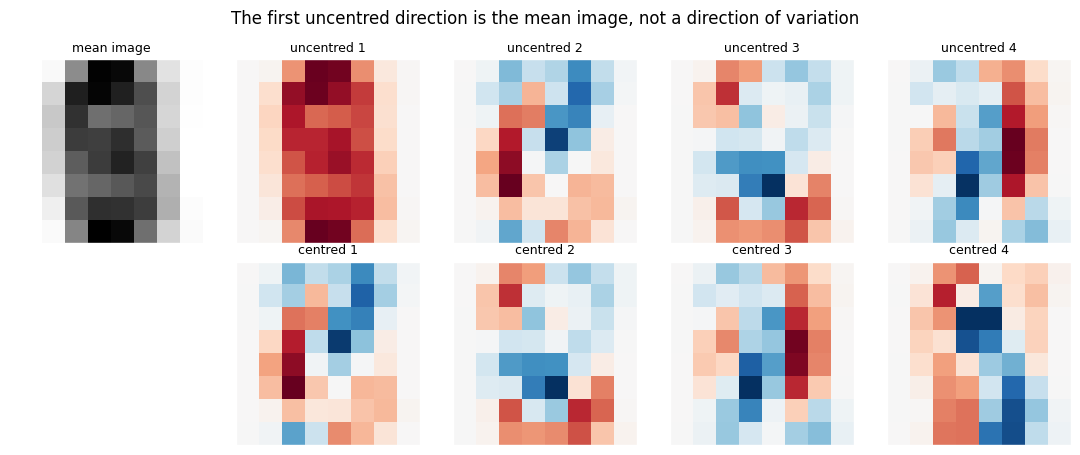

In [5]:
fig, ax = plt.subplots(2, 5, figsize=(11, 4.6))

ax[0, 0].imshow(mean_image.reshape(8, 8), cmap='gray_r')
ax[0, 0].set_title('mean image', fontsize=9)
ax[1, 0].axis('off')

for j in range(4):
    for row, V, name in [(0, V_unc, 'uncentred'), (1, V_cen, 'centred')]:
        img = V[:, j]
        lim = np.abs(img).max()
        a = ax[row, j + 1]
        a.imshow(img.reshape(8, 8), cmap='RdBu_r', vmin=-lim, vmax=lim)
        a.set_title('%s %d' % (name, j + 1), fontsize=9)

for a in ax.ravel():
    a.set_xticks([]); a.set_yticks([]); a.grid(False)

plt.suptitle('The first uncentred direction is the mean image, not a direction of variation')
plt.tight_layout()
plt.show()

## Derivation one: the directions of maximum variance

Work with the centred data and the sample covariance

$$\Sigma = \frac{1}{N-1}\sum_{i=1}^{N}\tilde{\mathbf{x}}_i\tilde{\mathbf{x}}_i^\top
= \frac{1}{N-1}\tilde{X}^\top\tilde{X} \in \mathbb{R}^{D\times D},$$

which is symmetric and positive semi-definite. Projecting onto a unit vector $\mathbf{w}$ gives scores
$z_i = \mathbf{w}^\top\tilde{\mathbf{x}}_i$ with mean zero and variance

$$\operatorname{Var}(z) = \frac{1}{N-1}\sum_i (\mathbf{w}^\top\tilde{\mathbf{x}}_i)^2
= \mathbf{w}^\top\Sigma\mathbf{w}.$$

Without the constraint $\lVert\mathbf{w}\rVert = 1$ this is unbounded, since scaling $\mathbf{w}$ by $c$ scales
the variance by $c^2$. With it, the Lagrangian is

$$\mathcal{L}(\mathbf{w}, \lambda) = \mathbf{w}^\top\Sigma\mathbf{w} - \lambda(\mathbf{w}^\top\mathbf{w} - 1),
\qquad
\frac{\partial\mathcal{L}}{\partial\mathbf{w}} = 2\Sigma\mathbf{w} - 2\lambda\mathbf{w} = \mathbf{0}
\quad\Longrightarrow\quad
\Sigma\mathbf{w} = \lambda\mathbf{w}.$$

So every stationary direction is an eigenvector of $\Sigma$. Which one is the maximum follows by substituting
back:

$$\operatorname{Var}(z) = \mathbf{w}^\top\Sigma\mathbf{w} = \mathbf{w}^\top(\lambda\mathbf{w}) = \lambda.$$

**The variance along an eigenvector is its eigenvalue.** The maximum is therefore attained at the eigenvector
with the largest eigenvalue, and the eigenvalues are not an incidental by-product of the decomposition — they
are the quantity the problem asked for.

The second component solves the same problem with the extra constraint $\mathbf{w}_2 \perp \mathbf{w}_1$. Adding
a second multiplier gives $\Sigma\mathbf{w}_2 = \lambda_2\mathbf{w}_2 + \mu\mathbf{w}_1$; left-multiplying by
$\mathbf{w}_1^\top$ and using $\mathbf{w}_1^\top\Sigma = \lambda_1\mathbf{w}_1^\top$ together with
$\mathbf{w}_1^\top\mathbf{w}_2 = 0$ gives $\mu = 0$, so $\mathbf{w}_2$ is again an eigenvector and, being
orthogonal to the first, it is the one with the second-largest eigenvalue. Repeating gives the whole ordered
eigenbasis.

Two consequences follow immediately. The components are orthogonal because $\Sigma$ is symmetric, and the
scores are **uncorrelated**: with $V$ the matrix of eigenvectors and $Z = \tilde{X}V$,

$$\operatorname{Cov}(Z) = \frac{1}{N-1}V^\top\tilde{X}^\top\tilde{X}V = V^\top\Sigma V = \Lambda,$$

a diagonal matrix. Uncorrelated is all that this gives, and the point where that becomes a limitation is where
`ica.ipynb` starts.

## Derivation two: the best rank-$k$ reconstruction

Now ask a different question. Choose an orthonormal basis $V_k \in \mathbb{R}^{D\times k}$ and reconstruct each
point by projecting it onto the span and back,

$$\hat{\mathbf{x}}_i = \bar{\mathbf{x}} + V_kV_k^\top\tilde{\mathbf{x}}_i,$$

then minimise the total squared error. Because $V_kV_k^\top$ is an orthogonal projection, Pythagoras applies to
each point:

$$\lVert\tilde{\mathbf{x}}_i\rVert^2 = \lVert V_kV_k^\top\tilde{\mathbf{x}}_i\rVert^2
+ \lVert(I - V_kV_k^\top)\tilde{\mathbf{x}}_i\rVert^2,$$

that is, *squared length = captured + discarded*. Summing over $i$,

$$\underbrace{\sum_i\lVert\tilde{\mathbf{x}}_i\rVert^2}_{\text{total, fixed}}
= \underbrace{\operatorname{tr}\!\left(V_k^\top \tilde{X}^\top\tilde{X} V_k\right)}_{\text{captured}}
+ \underbrace{\sum_i\lVert \mathbf{x}_i - \hat{\mathbf{x}}_i\rVert^2}_{\text{reconstruction error}}.$$

The left-hand side does not depend on $V_k$. **Minimising the reconstruction error is therefore exactly the
same problem as maximising the captured variance $\operatorname{tr}(V_k^\top\Sigma V_k)$**, which is the sum of
the projected variances along the $k$ chosen directions — the quantity the first derivation maximised one
direction at a time. The two formulations are one identity apart, and the solution of both is the leading $k$
eigenvectors of $\Sigma$.

The value at the optimum drops straight out. Since $\operatorname{tr}(V^\top\Sigma V) = \sum_j \lambda_j$ over
all $D$ components and the leading $k$ capture $\sum_{j\le k}\lambda_j$,

$$\frac{1}{N-1}\sum_i \lVert\mathbf{x}_i - \hat{\mathbf{x}}_i\rVert^2 = \sum_{j>k}\lambda_j.$$

The error left after $k$ components is the tail of the spectrum. This identity is checked numerically below and
holds to 2.2e-15.

One caveat on what is identified. The derivation constrains only the *span* of $V_k$ — the trace is unchanged
by replacing $V_k$ with $V_kR$ for any orthogonal $k\times k$ matrix $R$, since
$\operatorname{tr}(R^\top V_k^\top\Sigma V_kR) = \operatorname{tr}(V_k^\top\Sigma V_k)$. The reconstruction
problem alone does not pick out the individual axes at all. What picks them out is the *ordering* imposed by
the first derivation: solving one direction at a time, each orthogonal to the last, forces the axes to be
eigenvectors sorted by variance. That convention is the only reason PCA's components are well defined, and
`neural_networks/autoencoder.ipynb` shows what happens to a method that does not impose it.

## The class

`Principal_Component_Analysis` fits by either route. With `method='svd'` it takes the singular value
decomposition of the centred data matrix; with `method='eig'` it forms the covariance matrix and calls
`np.linalg.eigh`, the symmetric eigensolver. Both are exact in exact arithmetic; the section on numerics shows
where they part company in floating point.

Eigenvectors are returned in ascending order by `eigh` and are sign-ambiguous — if $\mathbf{v}$ is an
eigenvector so is $-\mathbf{v}$ — so `_fix_signs` applies a deterministic convention, making the entry of
largest magnitude in each component positive. Without it the same data can produce components that flip sign
between the two methods, or between machines, and every figure below would be unreproducible.

`transform` projects onto the components, `inverse_transform` maps back to pixel space, and `whiten` divides
each score by its standard deviation, producing scores with identity covariance. That last one is not used by
PCA itself; it is the preprocessing step `ica.ipynb` depends on, and it is defined here because it is a PCA
operation.

In [6]:
class Principal_Component_Analysis:
    def __init__(self, n_components=None, method='svd'):
        self.n_components = n_components
        self.method = method

    @staticmethod
    def _fix_signs(V):
        # deterministic sign convention: largest-magnitude entry of each component is positive
        signs = np.sign(V[np.argmax(np.abs(V), axis=0), np.arange(V.shape[1])])
        signs[signs == 0] = 1.0
        return V * signs

    def fit(self, X):
        n, d = X.shape
        self.mean = X.mean(axis=0)
        Xc = X - self.mean

        if self.method == 'svd':
            # singular values of the centred matrix; lambda_j = s_j^2 / (n - 1)
            U, s, Vt = np.linalg.svd(Xc, full_matrices=False)
            V = Vt.T
            self.singular_values = s
            eigenvalues = s ** 2 / (n - 1)
        elif self.method == 'eig':
            # covariance matrix, then the symmetric eigensolver
            cov = Xc.T @ Xc / (n - 1)
            w, V = np.linalg.eigh(cov)
            order = np.argsort(w)[::-1]                 # eigh returns ascending
            w, V = w[order], V[:, order]
            self.singular_values = np.sqrt(np.clip(w, 0, None) * (n - 1))
            eigenvalues = w
        else:
            raise ValueError('method must be svd or eig')

        self.components = self._fix_signs(V)
        self.eigenvalues = eigenvalues
        self.explained_variance_ratio = eigenvalues / eigenvalues.sum()
        self.total_variance = eigenvalues.sum()
        self.k = d if self.n_components is None else self.n_components
        return self

    def transform(self, X, k=None):
        k = self.k if k is None else k
        return (X - self.mean) @ self.components[:, :k]

    def inverse_transform(self, Z):
        k = Z.shape[1]
        return self.mean + Z @ self.components[:, :k].T

    def reconstruct(self, X, k=None):
        return self.inverse_transform(self.transform(X, k))

    def whiten(self, X, k=None):
        # scores divided by their standard deviations, so the result has identity covariance
        k = self.k if k is None else k
        return self.transform(X, k) / np.sqrt(self.eigenvalues[:k])

## Fitting, and checking the claims of the derivation

Every statement made above is now checked against the fitted object rather than assumed:

- the components are orthonormal, $V^\top V = I$;
- they satisfy the eigenvalue equation $\Sigma\mathbf{v}_j = \lambda_j\mathbf{v}_j$;
- the sample variance of the $j$-th score equals $\lambda_j$, which was the whole content of derivation one;
- the scores are uncorrelated, so the covariance of $Z$ is diagonal;
- the eigenvalues sum to the total variance of the data, so nothing is created or lost by the rotation.

In [7]:
pca = Principal_Component_Analysis(method='svd').fit(X_train)
Sigma = X_centred.T @ X_centred / (N - 1)
V = pca.components
lam = pca.eigenvalues
Z_train = pca.transform(X_train)

orthonormality = np.abs(V.T @ V - np.eye(D)).max()
eig_residual = np.abs(Sigma @ V - V * lam).max()
variance_gap = np.abs(Z_train.var(axis=0, ddof=1) - lam).max()
cov_offdiag = np.abs(np.cov(Z_train.T, ddof=1) - np.diag(lam)).max()

print('max |V^T V - I|                              %.2e' % orthonormality)
print('max |Sigma V - V Lambda|                     %.2e' % eig_residual)
print('max |Var(z_j) - lambda_j|                    %.2e' % variance_gap)
print('max off-diagonal of Cov(Z)                   %.2e' % cov_offdiag)
print()
print('sum of eigenvalues              %.6f' % lam.sum())
print('total variance of the raw data  %.6f' % X_train.var(axis=0, ddof=1).sum())
print()
print('first eight eigenvalues:', np.round(lam[:8], 5))
print('variance of the first eight scores:', np.round(Z_train.var(axis=0, ddof=1)[:8], 5))
print()
print('smallest four eigenvalues:', lam[-4:])
print('(two pixels are constant, so the covariance matrix has rank at most 62)')

max |V^T V - I|                              2.00e-15
max |Sigma V - V Lambda|                     2.16e-15
max |Var(z_j) - lambda_j|                    1.33e-15
max off-diagonal of Cov(Z)                   1.44e-15

sum of eigenvalues              4.700203
total variance of the raw data  4.700203

first eight eigenvalues: [0.68174 0.63447 0.55605 0.39173 0.27139 0.23557 0.21307 0.17166]
variance of the first eight scores: [0.68174 0.63447 0.55605 0.39173 0.27139 0.23557 0.21307 0.17166]

smallest four eigenvalues: [2.30137626e-06 1.40839848e-06 4.53670787e-33 4.48526529e-33]
(two pixels are constant, so the covariance matrix has rank at most 62)


## Explained variance and the scree plot

Dividing each eigenvalue by their sum gives the **explained variance ratio**

$$r_j = \frac{\lambda_j}{\sum_{l=1}^{D}\lambda_l},$$

the fraction of the total variance that component $j$ carries, and the cumulative sum $\sum_{j\le k} r_j$ is the
fraction carried by the leading $k$ together. Because the reconstruction error is the tail of the spectrum, the
cumulative curve read at $k$ is also one minus the fraction of squared error left after $k$ components — the
two panels below are the same information twice.

The **scree plot** is the ordered spectrum itself. It is read for the point where it stops falling steeply and
flattens into a tail; components past that point are each buying very little. On the digits there is no sharp
elbow — the curve bends over gradually between $k = 3$ and $k = 12$ — which is the usual situation and the
reason the criterion is a judgement rather than a rule. The cumulative curve gives something more definite: 21
components reach 90% of the variance and 29 reach 95%, out of 64.

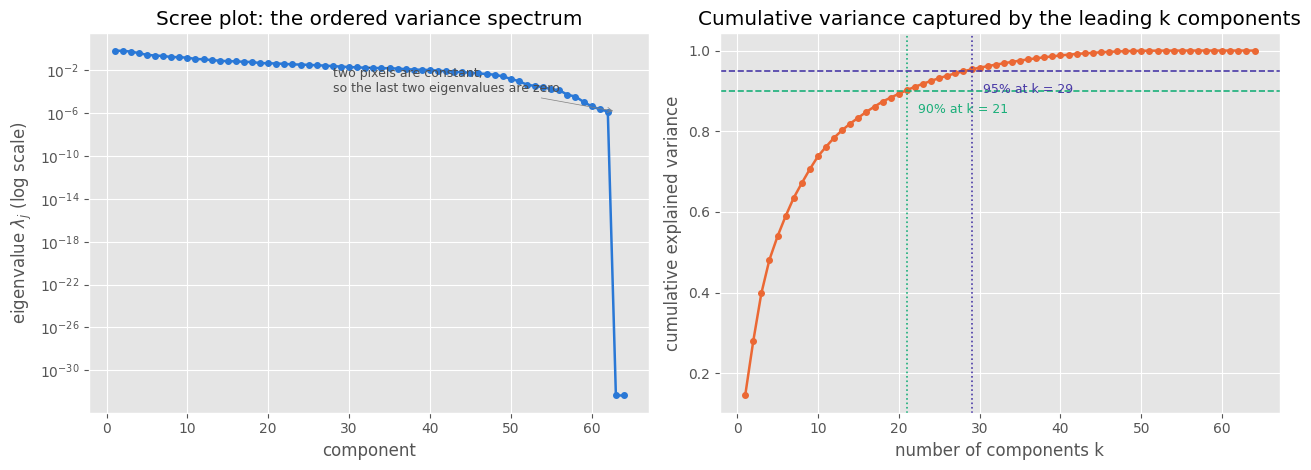

   k    ratio r_k     cumulative
   1      0.14504        0.14504
   2      0.13499        0.28003
   3      0.11830        0.39834
   5      0.05774        0.53942
  10      0.03159        0.73784
  21      0.00900        0.90200
  29      0.00466        0.95339
  42      0.00171        0.99158
  62      0.00000        1.00000
  64      0.00000        1.00000

50% of the variance needs 5 of 64 components
80% of the variance needs 13 of 64 components
90% of the variance needs 21 of 64 components
95% of the variance needs 29 of 64 components
99% of the variance needs 42 of 64 components


In [8]:
evr = pca.explained_variance_ratio
cumulative = np.cumsum(evr)
thresholds = [0.5, 0.8, 0.9, 0.95, 0.99]
needed = {t: int(np.searchsorted(cumulative, t) + 1) for t in thresholds}

fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))

ax[0].plot(np.arange(1, D + 1), lam, 'o-', color=blue, lw=1.8, ms=4)
ax[0].set_yscale('log')
ax[0].set_xlabel('component')
ax[0].set_ylabel(r'eigenvalue $\lambda_j$ (log scale)')
ax[0].set_title('Scree plot: the ordered variance spectrum')
ax[0].annotate('two pixels are constant,\nso the last two eigenvalues are zero',
               xy=(63, max(lam[-3], 1e-8)), xytext=(28, 1e-4), fontsize=9, color='0.3',
               arrowprops=dict(arrowstyle='->', color='0.5'))

ax[1].plot(np.arange(1, D + 1), cumulative, 'o-', color=orange, lw=1.8, ms=4)
for t, col in zip([0.9, 0.95], [green, purple]):
    ax[1].axhline(t, color=col, ls='--', lw=1.2)
    ax[1].axvline(needed[t], color=col, ls=':', lw=1.2)
    ax[1].annotate('%d%% at k = %d' % (100 * t, needed[t]), (needed[t], t),
                   textcoords='offset points', xytext=(8, -16), fontsize=9, color=col)
ax[1].set_xlabel('number of components k')
ax[1].set_ylabel('cumulative explained variance')
ax[1].set_title('Cumulative variance captured by the leading k components')

plt.tight_layout()
plt.show()

print('%4s %12s %14s' % ('k', 'ratio r_k', 'cumulative'))
for k in [1, 2, 3, 5, 10, 21, 29, 42, 62, 64]:
    print('%4d %12.5f %14.5f' % (k, evr[k - 1], cumulative[k - 1]))
print()
for t in thresholds:
    print('%.0f%% of the variance needs %d of %d components' % (100 * t, needed[t], D))

## Reconstruction

The identity derived above says the mean squared reconstruction error per image is the tail of the spectrum,

$$\frac{1}{N}\sum_i\lVert\mathbf{x}_i - \hat{\mathbf{x}}_i\rVert^2 = \frac{N-1}{N}\sum_{j>k}\lambda_j
= \frac{1}{N}\sum_{j>k}s_j^2,$$

with $s_j$ the singular values of the centred data matrix. The table below measures the error directly and
compares it against the discarded singular values; they agree to 2.2e-15, which is floating-point equality.

The test column is the same calculation on the 1,124 held-out images, using the mean and components fitted on
the training set. It is barely worse than the training column, and that is a property worth naming: PCA has
$Dk$ parameters in the components and is fitted by a decomposition rather than by search, so there is very
little to overfit at these values of $k$. It is also the point of contrast with t-SNE, which has no way to
produce this column at all.

In [9]:
ks = [2, 4, 8, 16, 32]


def recon_loss(X, R):
    return np.mean(np.sum((X - R) ** 2, axis=1))


def per_pixel_rmse(X, R):
    return np.sqrt(np.mean((X - R) ** 2))


print('%4s %12s %18s %12s %12s' % ('k', 'J train', 'sum s^2 / N', 'J test', 'RMSE test'))
gaps = []
for k in ks:
    tail = (pca.singular_values[k:] ** 2).sum() / N
    tr = recon_loss(X_train, pca.reconstruct(X_train, k))
    te = recon_loss(X_test, pca.reconstruct(X_test, k))
    gaps.append(abs(tr - tail))
    print('%4d %12.5f %18.5f %12.5f %12.5f'
          % (k, tr, tail, te, per_pixel_rmse(X_test, pca.reconstruct(X_test, k))))

print()
print('largest disagreement between measured error and the discarded spectrum: %.2e' % max(gaps))

   k      J train        sum s^2 / N       J test    RMSE test
   2      3.38324            3.38324      3.39121      0.23019
   4      2.43566            2.43566      2.43096      0.19489
   8      1.54416            1.54416      1.56034      0.15614
  16      0.71291            0.71291      0.72799      0.10665
  32      0.16385            0.16385      0.17325      0.05203

largest disagreement between measured error and the discarded spectrum: 2.22e-15


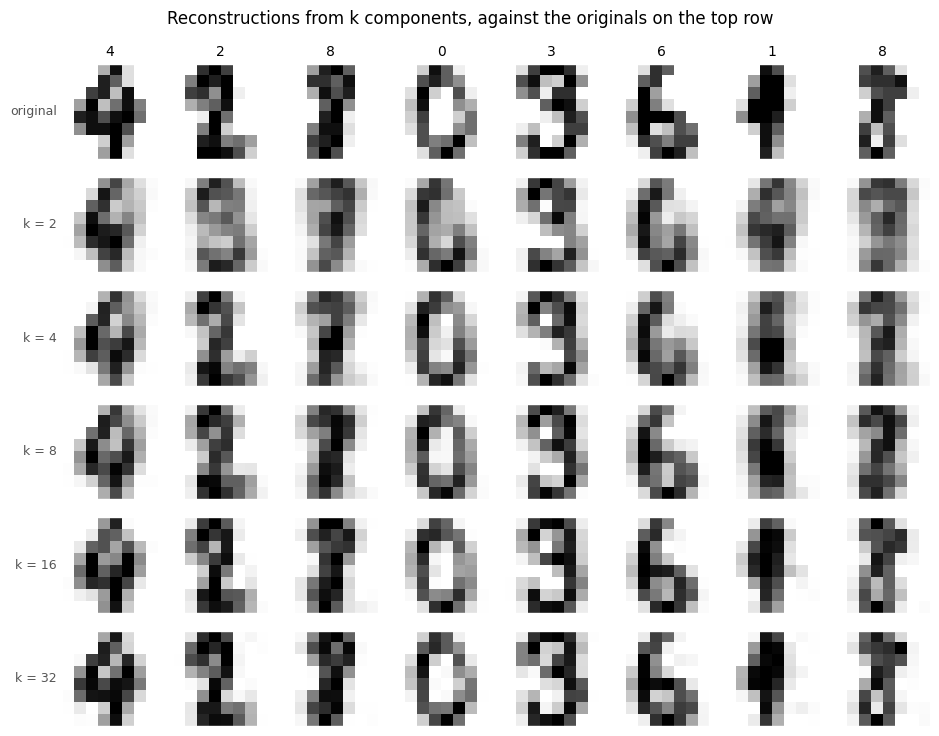

In [10]:
show = np.arange(8)
rows = [('original', X_train[show])] + [('k = %d' % k, pca.reconstruct(X_train, k)[show]) for k in ks]

fig, ax = plt.subplots(len(rows), 8, figsize=(9.5, 1.25 * len(rows)))

for r, (label, images) in enumerate(rows):
    for c in range(8):
        a = ax[r, c]
        a.imshow(images[c].reshape(8, 8), cmap='gray_r', vmin=0, vmax=1)
        a.set_xticks([]); a.set_yticks([]); a.grid(False)
        if c == 0:
            a.set_ylabel(label, rotation=0, ha='right', va='center', fontsize=9)
        if r == 0:
            a.set_title(str(y_train[show[c]]), fontsize=10)

plt.suptitle('Reconstructions from k components, against the originals on the top row')
plt.tight_layout()
plt.show()

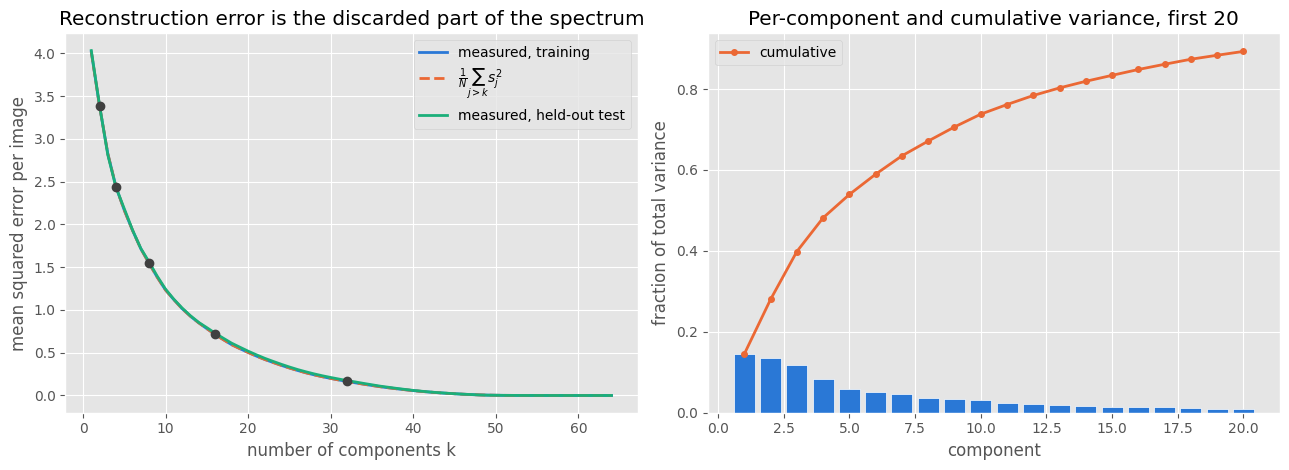

In [11]:
k_grid = np.arange(1, D + 1)
train_curve = np.array([recon_loss(X_train, pca.reconstruct(X_train, k)) for k in k_grid])
test_curve = np.array([recon_loss(X_test, pca.reconstruct(X_test, k)) for k in k_grid])
tail_curve = np.array([(pca.singular_values[k:] ** 2).sum() / N for k in k_grid])

fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))

ax[0].plot(k_grid, train_curve, color=blue, lw=2, label='measured, training')
ax[0].plot(k_grid, tail_curve, color=orange, lw=2, ls='--', label=r'$\frac{1}{N}\sum_{j>k}s_j^2$')
ax[0].plot(k_grid, test_curve, color=green, lw=2, label='measured, held-out test')
for k in ks:
    ax[0].plot(k, train_curve[k - 1], marker='o', ms=6, color='0.25')
ax[0].set_xlabel('number of components k')
ax[0].set_ylabel('mean squared error per image')
ax[0].set_title('Reconstruction error is the discarded part of the spectrum')
ax[0].legend()

a = ax[1]
a.bar(np.arange(1, 21), evr[:20], color=blue, edgecolor='white')
a.plot(np.arange(1, 21), cumulative[:20], 'o-', color=orange, lw=2, ms=4,
       label='cumulative')
a.set_xlabel('component')
a.set_ylabel('fraction of total variance')
a.set_title('Per-component and cumulative variance, first 20')
a.legend()

plt.tight_layout()
plt.show()

## What the components look like

Each component is a vector of 64 numbers, one per pixel, so it folds back into an 8x8 image. The
reconstruction is

$$\hat{\mathbf{x}} = \bar{\mathbf{x}} + \sum_{j=1}^{k} z_j\,\mathbf{v}_j,$$

so the components are the images being added to the mean and the scores say how much of each. Red and blue in
the figure are opposite signs: a component describes a contrast, ink here against ink there, and its score is
positive for digits with the red pattern and negative for digits with the blue one.

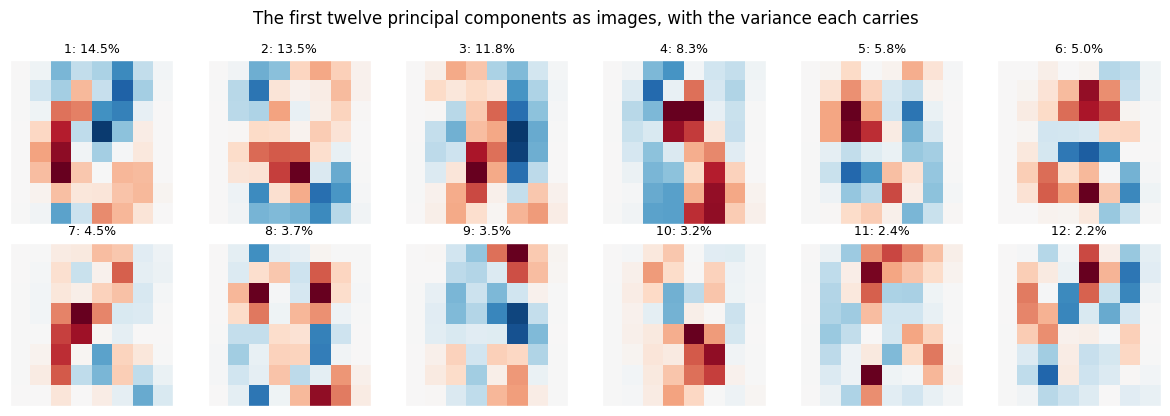

In [12]:
fig, ax = plt.subplots(2, 6, figsize=(12, 4.2))

for j, a in enumerate(ax.ravel()):
    img = V[:, j]
    lim = np.abs(img).max()
    a.imshow(img.reshape(8, 8), cmap='RdBu_r', vmin=-lim, vmax=lim)
    a.set_title('%d: %.1f%%' % (j + 1, 100 * evr[j]), fontsize=9)
    a.set_xticks([]); a.set_yticks([]); a.grid(False)

plt.suptitle('The first twelve principal components as images, with the variance each carries')
plt.tight_layout()
plt.show()

## Checking that the two derivations really do give the same answer

The equivalence was argued algebraically. It can also be measured, by solving each problem numerically without
ever calling an eigensolver on the covariance matrix and then comparing the answers with the fitted components.

**The variance problem, by orthogonal iteration.** Repeatedly multiplying a $D\times k$ matrix by $\Sigma$ and
re-orthonormalising it converges to the invariant subspace of the $k$ largest eigenvalues, because each
multiplication amplifies a direction by its eigenvalue and the largest ones win. This is a direct attack on
$\max \operatorname{tr}(B^\top\Sigma B)$ that uses only matrix products and a QR factorisation.

**The reconstruction problem, by gradient descent.** Parametrise the reconstruction as
$\hat{X} = \tilde{X}W_1W_2$ with $W_1 \in \mathbb{R}^{D\times k}$ and $W_2 \in \mathbb{R}^{k\times D}$
unconstrained — neither orthogonal nor ordered — and run plain gradient descent on
$J = \frac{1}{N}\lVert\tilde{X} - \tilde{X}W_1W_2\rVert_F^2$. This is exactly the linear autoencoder of
`neural_networks/autoencoder.ipynb`, written here in six lines to make the comparison self-contained.

The gradients are
$\partial J/\partial W_2 = \frac{2}{N}(\tilde{X}W_1)^\top E$ and
$\partial J/\partial W_1 = \frac{2}{N}\tilde{X}^\top E W_2^\top$ with $E = \tilde{X}W_1W_2 - \tilde{X}$.

Subspaces are compared by **principal angles**: take orthonormal bases $Q_1, Q_2$ of the two spans, and the
singular values of $Q_1^\top Q_2$ are the cosines of the angles between them. All angles zero means the spans
are identical.

In [13]:
def orthogonal_iteration(Sigma, k, iters=300, seed=0):
    # repeated multiplication by Sigma, re-orthonormalised each step
    r = np.random.default_rng(seed)
    B = r.normal(size=(Sigma.shape[0], k))
    for _ in range(iters):
        B, _ = np.linalg.qr(Sigma @ B)
    return B, np.diag(B.T @ Sigma @ B)


def linear_autoencoder(Xc, k, steps=8000, lr=0.4, seed=0):
    # plain gradient descent on the rank-k reconstruction error, no constraints on W1, W2
    r = np.random.default_rng(seed)
    n = len(Xc)
    W1 = r.normal(0, 0.1, size=(Xc.shape[1], k))
    W2 = r.normal(0, 0.1, size=(k, Xc.shape[1]))
    history = []
    for t in range(steps):
        H = Xc @ W1
        E = H @ W2 - Xc
        W1 = W1 - lr * (Xc.T @ (E @ W2.T)) * 2 / n
        W2 = W2 - lr * (H.T @ E) * 2 / n
        if t % 100 == 0:
            history.append(np.mean(np.sum(E ** 2, axis=1)))
    return W1, W2, history


def principal_angles(A, B):
    Q1, _ = np.linalg.qr(A)
    Q2, _ = np.linalg.qr(B)
    cosines = np.linalg.svd(Q1.T @ Q2, compute_uv=False)
    return np.degrees(np.arccos(np.clip(cosines, -1, 1)))


k_demo = 8
start = time.time()
B_power, lam_power = orthogonal_iteration(Sigma, k_demo)
W1, W2, ae_history = linear_autoencoder(X_centred, k_demo)
elapsed = time.time() - start

Vk = V[:, :k_demo]
J_pca = recon_loss(X_train, pca.reconstruct(X_train, k_demo))
J_ae = recon_loss(X_train, mean_image + X_centred @ W1 @ W2)

print('k = %d, both problems solved without touching the fitted components' % k_demo)
print()
print('variance problem, orthogonal iteration')
print('  eigenvalues recovered      ', np.round(lam_power, 8))
print('  eigenvalues from the fit   ', np.round(lam[:k_demo], 8))
print('  principal angles to PCA    ', np.round(principal_angles(B_power, Vk), 8), 'degrees')
print()
print('reconstruction problem, gradient descent on an unconstrained rank-%d map' % k_demo)
print('  J from gradient descent %.5f' % J_ae)
print('  J from PCA              %.5f' % J_pca)
print('  ratio                   %.6f' % (J_ae / J_pca))
print('  principal angles to PCA ', np.round(principal_angles(W2.T, Vk), 4), 'degrees')
print()
print('W2 rows orthonormal? max |W2 W2^T - I| = %.3f' % np.abs(W2 @ W2.T - np.eye(k_demo)).max())
print('largest |correlation| between a W2 row and its matching component: %.4f'
      % np.abs((W2 / np.linalg.norm(W2, axis=1, keepdims=True)) @ Vk).max())
print()
print('fitting time %.1f s' % elapsed)

k = 8, both problems solved without touching the fitted components

variance problem, orthogonal iteration
  eigenvalues recovered       [0.6817397  0.63447259 0.55605323 0.39173492 0.27138962 0.23557204
 0.21307457 0.17165895]
  eigenvalues from the fit    [0.6817397  0.63447259 0.55605323 0.39173492 0.27138962 0.23557204
 0.21307457 0.17165895]
  principal angles to PCA     [0.000e+00 0.000e+00 0.000e+00 0.000e+00 8.500e-07 1.210e-06 1.910e-06
 1.586e-05] degrees

reconstruction problem, gradient descent on an unconstrained rank-8 map
  J from gradient descent 1.54417
  J from PCA              1.54416
  ratio                   1.000005
  principal angles to PCA  [0.0001 0.0006 0.0008 0.0009 0.0014 0.0021 0.0024 0.0032] degrees

W2 rows orthonormal? max |W2 W2^T - I| = 0.170
largest |correlation| between a W2 row and its matching component: 0.7522

fitting time 3.9 s


Orthogonal iteration recovers the same eigenvalues to eight decimals and the same subspace to within
1.6e-05 degrees. Gradient descent on the reconstruction error reaches $J = 1.54417$ against PCA's exact
$1.54416$, a ratio of 1.000005, and its principal angles to the PCA subspace are at most 0.0032 degrees.

The last two lines are the caveat that matters. $W_2W_2^\top$ is nowhere near the identity, so the learned
axes are not orthonormal, and no row of $W_2$ lines up with a principal component. This is the same
non-identifiability the reconstruction derivation predicted: for any invertible $A$,

$$W_1W_2 = (W_1A^{-1})(AW_2),$$

so the objective cannot distinguish a solution from any rotated, rescaled or sheared version of it. The span is
learned; the coordinate system on it is arbitrary. `neural_networks/autoencoder.ipynb` reaches the same
conclusion on the same data with a proper Adam-trained network — reconstruction ratios of 1.00018 to 1.00555
across $k$, and principal angles averaging a fraction of a degree, with decoder rows that match no component —
and this cell is a compressed version of that result computed here so the two notebooks can be checked against
each other.

What PCA adds on top of the subspace is the *ordering*: axes that are orthogonal, uncorrelated in score, and
sorted so that truncating at any $k$ is optimal. That is a convention imposed by the sequential variance
derivation, not something the reconstruction error ever asked for.

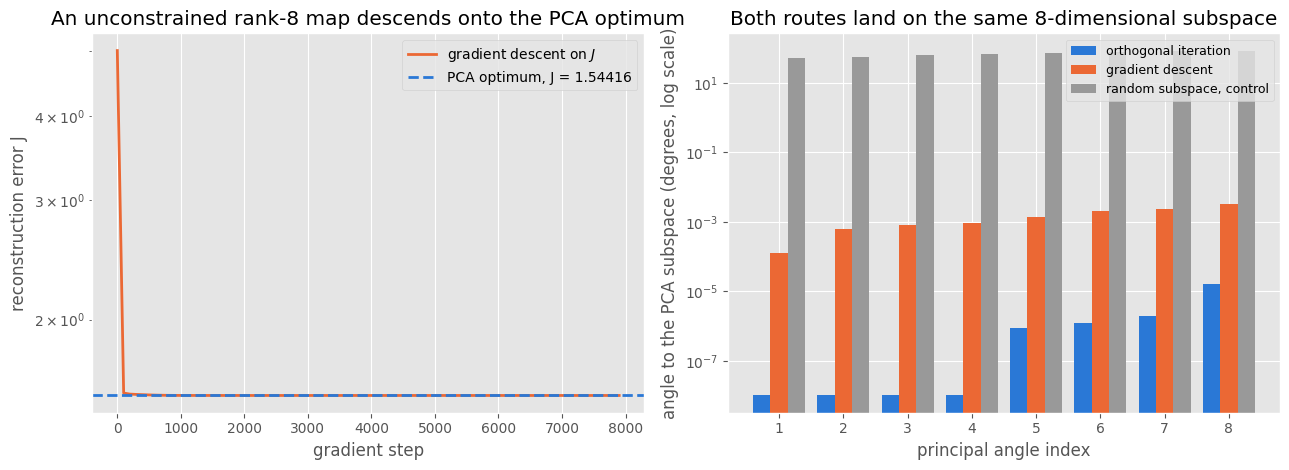

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))

steps_axis = np.arange(len(ae_history)) * 100
ax[0].plot(steps_axis, ae_history, color=orange, lw=2, label='gradient descent on $J$')
ax[0].axhline(J_pca, color=blue, lw=2, ls='--', label='PCA optimum, J = %.5f' % J_pca)
ax[0].set_yscale('log')
ax[0].set_xlabel('gradient step')
ax[0].set_ylabel('reconstruction error J')
ax[0].set_title('An unconstrained rank-8 map descends onto the PCA optimum')
ax[0].legend()

angles_ae = principal_angles(W2.T, Vk)
angles_power = principal_angles(B_power, Vk)
r_ctrl = np.random.default_rng(1)
angles_random = principal_angles(r_ctrl.normal(size=(D, k_demo)), Vk)

width = 0.27
pos = np.arange(1, k_demo + 1)
ax[1].bar(pos - width, np.maximum(angles_power, 1e-8), width, color=blue, label='orthogonal iteration')
ax[1].bar(pos, np.maximum(angles_ae, 1e-8), width, color=orange, label='gradient descent')
ax[1].bar(pos + width, angles_random, width, color='0.6', label='random subspace, control')
ax[1].set_yscale('log')
ax[1].set_xlabel('principal angle index')
ax[1].set_ylabel('angle to the PCA subspace (degrees, log scale)')
ax[1].set_title('Both routes land on the same 8-dimensional subspace')
ax[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

## The SVD route, and why it is the one to use

The singular value decomposition of the centred data matrix is

$$\tilde{X} = U S V^\top, \qquad U^\top U = I,\; V^\top V = I,\; S = \operatorname{diag}(s_1 \ge \dots \ge s_D \ge 0).$$

Substituting into the covariance,

$$\Sigma = \frac{\tilde{X}^\top\tilde{X}}{N-1} = \frac{VS U^\top U S V^\top}{N-1} = V\frac{S^2}{N-1}V^\top,$$

which is an eigendecomposition of $\Sigma$ with eigenvectors $V$ and eigenvalues $\lambda_j = s_j^2/(N-1)$.
The right singular vectors of the centred data *are* the principal components, and no covariance matrix has to
be formed to get them. The scores come out as $Z = \tilde{X}V = US$.

In exact arithmetic the two routes are identical, and the cell below confirms that they agree on this dataset
to about 1e-15. In floating point they are not, and the reason is the squaring. The relevant quantity is the
condition number $\kappa = s_{\max}/s_{\min}$, which controls how much a relative perturbation in the input can
be amplified in the answer. Forming $\tilde{X}^\top\tilde{X}$ squares the singular values, so

$$\kappa(\tilde{X}^\top\tilde{X}) = \kappa(\tilde{X})^2.$$

A matrix whose singular values span $10^{9}$ becomes a covariance matrix whose eigenvalues span $10^{18}$,
which is past the $\approx 2.2\times10^{-16}$ resolution of float64. Everything below the resolution of the
largest eigenvalue is destroyed by the rounding of the matrix product itself, before any eigensolver runs.
Roughly, the eigenvalue route can be trusted for about half as many digits as the SVD route.

The demonstration below is a matrix built with known singular values spaced logarithmically from $1$ down to
$10^{-9}$, in an $n \times p$ matrix with random orthogonal factors, so the truth is available for comparison.
Both routes recover the same leading singular values; they diverge in the tail.

In [15]:
print('agreement of the two routes on the digits')
pca_eig = Principal_Component_Analysis(method='eig').fit(X_train)
print('  max |lambda_svd - lambda_eig|     %.2e' % np.abs(pca.eigenvalues - pca_eig.eigenvalues).max())
print('  max angle between components      %.2e degrees'
      % np.degrees(np.arccos(np.clip(np.abs((pca.components * pca_eig.components).sum(axis=0)), -1, 1))).max())
print('  smallest eigenvalue, svd route    %.3e' % pca.eigenvalues[-1])
print('  smallest eigenvalue, eig route    %.3e' % pca_eig.eigenvalues[-1])
print()

# a matrix with known singular values spanning nine orders of magnitude
r_cond = np.random.default_rng(3)
p, n_rows = 8, 60
Q_left, _ = np.linalg.qr(r_cond.normal(size=(n_rows, p)))
Q_right, _ = np.linalg.qr(r_cond.normal(size=(p, p)))
s_true = np.logspace(0, -9, p)
X_hard = Q_left @ np.diag(s_true) @ Q_right.T

gram = X_hard.T @ X_hard
ev, evec = np.linalg.eigh(gram)
ev, evec = ev[::-1], evec[:, ::-1]
s_from_eig = np.sqrt(np.clip(ev, 0, None))
_, s_from_svd, Vt_hard = np.linalg.svd(X_hard, full_matrices=False)

print('condition number of X          %.1e' % (s_true[0] / s_true[-1]))
print('condition number of X^T X      %.1e' % ((s_true[0] / s_true[-1]) ** 2))
print('float64 resolution             %.1e' % np.finfo(float).eps)
print()
print('%3s %16s %18s %11s %16s %11s' % ('j', 'true sigma', 'via eig(X^T X)', 'rel err', 'via svd(X)', 'rel err'))
for j in range(p):
    print('%3d %16.6e %18.6e %11.1e %16.6e %11.1e'
          % (j, s_true[j], s_from_eig[j], abs(s_from_eig[j] - s_true[j]) / s_true[j],
             s_from_svd[j], abs(s_from_svd[j] - s_true[j]) / s_true[j]))

ang_eig = np.array([np.degrees(np.arccos(np.clip(abs(evec[:, j] @ Q_right[:, j]), 0, 1))) for j in range(p)])
ang_svd = np.array([np.degrees(np.arccos(np.clip(abs(Vt_hard[j] @ Q_right[:, j]), 0, 1))) for j in range(p)])
print()
print('angle to the true direction, eig route:', np.round(ang_eig, 4))
print('angle to the true direction, svd route:', np.round(ang_svd, 4))

agreement of the two routes on the digits
  max |lambda_svd - lambda_eig|     1.19e-15
  max angle between components      3.19e-06 degrees
  smallest eigenvalue, svd route    4.485e-33
  smallest eigenvalue, eig route    0.000e+00

condition number of X          1.0e+09
condition number of X^T X      1.0e+18
float64 resolution             2.2e-16

  j       true sigma     via eig(X^T X)     rel err       via svd(X)     rel err
  0     1.000000e+00       1.000000e+00     2.2e-16     1.000000e+00     2.2e-16
  1     5.179475e-02       5.179475e-02     4.8e-15     5.179475e-02     4.0e-16
  2     2.682696e-03       2.682696e-03     1.7e-12     2.682696e-03     3.4e-15
  3     1.389495e-04       1.389495e-04     3.9e-09     1.389495e-04     1.2e-13
  4     7.196857e-06       7.196853e-06     5.0e-07     7.196857e-06     2.7e-13
  5     3.727594e-07       3.726895e-07     1.9e-04     3.727594e-07     4.6e-12
  6     1.930698e-08       2.041474e-08     5.7e-02     1.930698e-08     8.2e-11
 

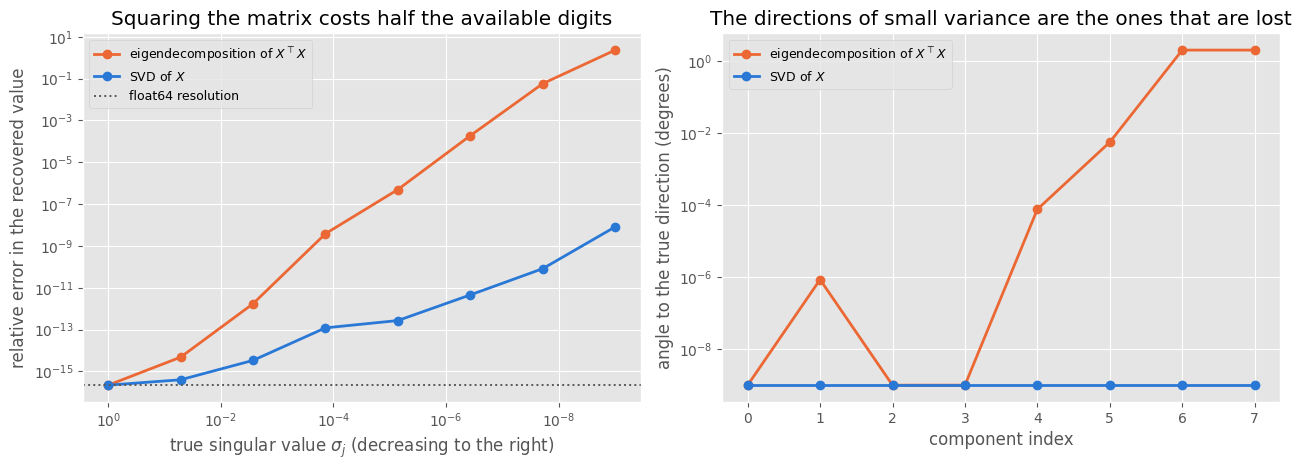

In [16]:
rel_eig = np.abs(s_from_eig - s_true) / s_true
rel_svd = np.abs(s_from_svd - s_true) / s_true

fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))

ax[0].plot(s_true, np.maximum(rel_eig, 1e-17), 'o-', color=orange, lw=2, label=r'eigendecomposition of $X^\top X$')
ax[0].plot(s_true, np.maximum(rel_svd, 1e-17), 'o-', color=blue, lw=2, label=r'SVD of $X$')
ax[0].axhline(np.finfo(float).eps, color='0.35', ls=':', lw=1.4, label='float64 resolution')
ax[0].set_xscale('log'); ax[0].set_yscale('log')
ax[0].invert_xaxis()
ax[0].set_xlabel(r'true singular value $\sigma_j$ (decreasing to the right)')
ax[0].set_ylabel('relative error in the recovered value')
ax[0].set_title('Squaring the matrix costs half the available digits')
ax[0].legend(fontsize=9, loc='upper left')

ax[1].plot(np.arange(p), np.maximum(ang_eig, 1e-9), 'o-', color=orange, lw=2, label=r'eigendecomposition of $X^\top X$')
ax[1].plot(np.arange(p), np.maximum(ang_svd, 1e-9), 'o-', color=blue, lw=2, label=r'SVD of $X$')
ax[1].set_yscale('log')
ax[1].set_xlabel('component index')
ax[1].set_ylabel('angle to the true direction (degrees)')
ax[1].set_title('The directions of small variance are the ones that are lost')
ax[1].legend(fontsize=9, loc='upper left')

plt.tight_layout()
plt.show()

The leading four singular values come back from both routes with a relative error near machine precision. From
there the eigenvalue route degrades steadily — a relative error of 3.9e-09 at $\sigma = 1.4\times10^{-4}$,
1.9e-04 at $\sigma = 3.7\times10^{-7}$, and 2.30 at $\sigma = 10^{-9}$, meaning the smallest singular value is
recovered as roughly three times its true size. The SVD route stays at 8.2e-09 or better throughout. The
directions tell the same story: the last two eigenvectors of $X^\top X$ are 2.0 degrees away from the truth,
while every SVD direction is correct to within a rounding error.

On the digits the two routes agree to 1.2e-15 in the eigenvalues and to 3.2e-06 degrees in the components,
because the leading eigenvalues are all of comparable size and there is nothing delicate to lose. The one place
the difference shows even here is at the bottom of the spectrum: the covariance route returns the smallest
eigenvalue as exactly $0$, while the SVD route returns $4.5\times10^{-33}$, obtained as
$s^2/(N-1)$ with $s = 4.5\times10^{-15}$. There is no useful information in either — both correctly say the
direction is empty — but it illustrates the mechanism, since a singular value the SVD can still represent
becomes an eigenvalue that has underflowed past anything the covariance matrix could hold.

The practical rule is simple: use the SVD of the centred data. It costs no more, it needs no $D\times D$ matrix
to be formed, and it is the accurate route whenever the spectrum has any range to it. The eigenvalue route is
worth knowing because it is what makes the *derivation* clear, not because it is what should be run.

## The projection as a picture, and as a transform

Projecting onto the first two components gives a two-dimensional map, drawn below and coloured by the digit
label, which took no part in fitting. Some structure is visible — zeros separate, fours and ones sit apart —
but most classes overlap heavily, because two components hold only 28.0% of the variance.

The number under the picture is a **1-nearest-neighbour label agreement**: for each test point, find the
nearest other test point in the representation and ask whether the labels match. It measures how much class
structure a representation keeps, with chance at about 10%. On the raw 64 pixels it is 0.9706. On the PCA
plane it is 0.5480 for the 1,000-point subset used in `tsne.ipynb`, and 0.5418 on the full test set, which is
the number `neural_networks/autoencoder.ipynb` reports for the same projection.

The second panel is the property PCA has and the other two notebooks do not have in the same form. The
components were fitted on the training set; applying them to the 1,124 held-out images is a matrix
multiplication, and the held-out points land in the same places relative to the training ones. A new digit
arriving tomorrow is projected the same way, at the cost of one matrix product.

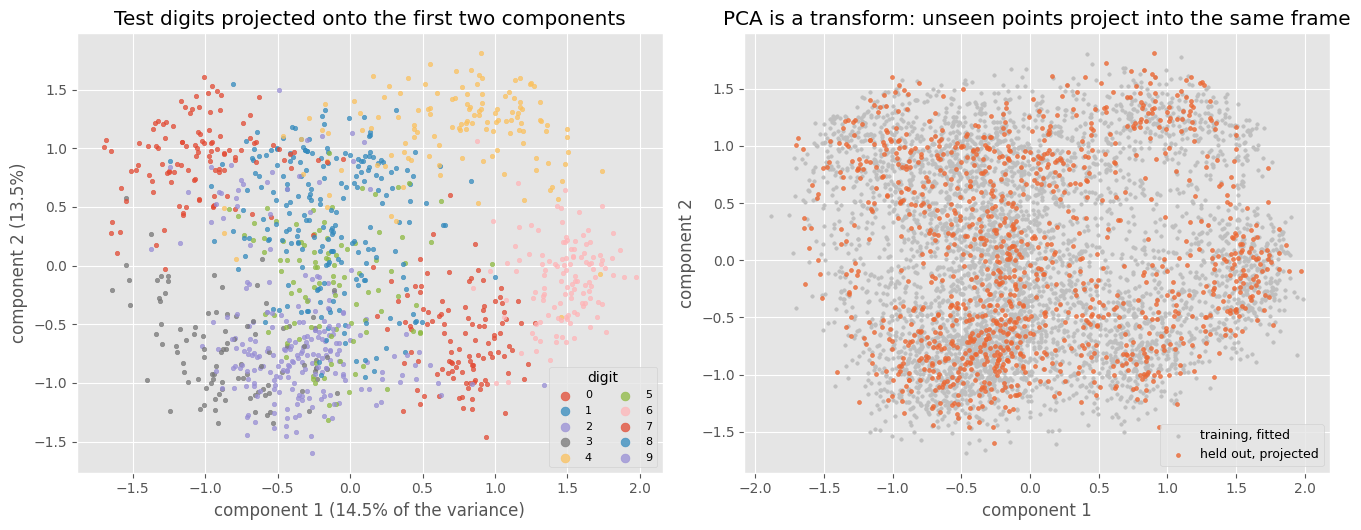

representation                       dims     1-NN label agreement
raw pixels                             64                   0.9706
PCA, 2 components                       2                   0.5418
PCA, 4 components                       4                   0.8007
PCA, 8 components                       8                   0.9422
PCA, 16 components                     16                   0.9617
PCA, 32 components                     32                   0.9715


In [17]:
def neighbour_agreement(Z, y):
    sq = (Z ** 2).sum(axis=1)
    d = sq[:, None] + sq[None, :] - 2 * (Z @ Z.T)
    np.fill_diagonal(d, np.inf)
    return (y[d.argmin(axis=1)] == y).mean()


Z_test_2 = pca.transform(X_test, 2)
Z_train_2 = pca.transform(X_train, 2)

fig, ax = plt.subplots(1, 2, figsize=(13.5, 5.4))

for d in range(10):
    m = y_test == d
    ax[0].scatter(Z_test_2[m, 0], Z_test_2[m, 1], s=10, alpha=0.75, label=str(d))
ax[0].set_xlabel('component 1 (%.1f%% of the variance)' % (100 * evr[0]))
ax[0].set_ylabel('component 2 (%.1f%%)' % (100 * evr[1]))
ax[0].set_title('Test digits projected onto the first two components')
ax[0].legend(title='digit', markerscale=2, ncol=2, fontsize=8)

ax[1].scatter(Z_train_2[:, 0], Z_train_2[:, 1], s=6, color='0.75', label='training, fitted')
ax[1].scatter(Z_test_2[:, 0], Z_test_2[:, 1], s=8, color=orange, alpha=0.8, label='held out, projected')
ax[1].set_xlabel('component 1')
ax[1].set_ylabel('component 2')
ax[1].set_title('PCA is a transform: unseen points project into the same frame')
ax[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print('%-34s %6s %24s' % ('representation', 'dims', '1-NN label agreement'))
print('%-34s %6d %24.4f' % ('raw pixels', D, neighbour_agreement(X_test, y_test)))
for k in [2, 4, 8, 16, 32]:
    print('%-34s %6d %24.4f' % ('PCA, %d components' % k, k,
                                neighbour_agreement(pca.transform(X_test, k), y_test)))

## Whitening, and the handover to ICA

Dividing each score by its standard deviation gives the **whitened** representation

$$\mathbf{z} = \Lambda_k^{-1/2}V_k^\top(\mathbf{x} - \bar{\mathbf{x}}), \qquad \operatorname{Cov}(\mathbf{z}) = I.$$

Every direction now has unit variance and every pair of coordinates is uncorrelated. This is the standard
preprocessing step for ICA, and the reason it matters there is worth stating here because it is a fact about
PCA: after whitening, any remaining mixing matrix must be **orthogonal**. If $\mathbf{z} = A\mathbf{s}$ with
$\operatorname{Cov}(\mathbf{s}) = I$ and $\operatorname{Cov}(\mathbf{z}) = I$, then
$I = A\operatorname{Cov}(\mathbf{s})A^\top = AA^\top$. Whitening therefore reduces the search from the $D^2$
entries of a general matrix to the $D(D-1)/2$ of a rotation, and PCA is what performs it.

What whitening does **not** do is make the coordinates independent, and that is the whole reason ICA exists.
Uncorrelatedness constrains second moments only:

$$\mathbb{E}[z_1z_2] = \mathbb{E}[z_1]\mathbb{E}[z_2],$$

whereas independence requires $p(z_1, z_2) = p(z_1)p(z_2)$, which constrains every moment and every functional
of the joint density at once. For jointly Gaussian variables the two coincide, since a Gaussian is fully
described by its mean and covariance. For anything else they do not.

The demonstration below takes two independent uniform sources, mixes them with a fixed $2\times2$ matrix, and
runs PCA on the mixture. The resulting scores are uncorrelated to 8.7e-16 — the algebra guarantees it — while
a histogram estimate of the mutual information

$$I(z_1; z_2) = \sum_{a,b} p_{ab}\log\frac{p_{ab}}{p_a p_b}$$

reads 0.257 nats against 0.013 for the true sources, and the correlation between the *squares* of the two
coordinates is -0.39 where the sources give -0.01. The scores are uncorrelated and plainly dependent. Finding
the rotation that fixes this is the subject of `ica.ipynb`.

correlation between the two PCA scores           8.73e-16
covariance of the whitened scores, max |off - I| 1.55e-15

mutual information, true independent sources     0.01311 nats
mutual information, uncorrelated PCA scores      0.25694 nats

correlation of the squares, true sources         -0.0089
correlation of the squares, PCA scores           -0.3914


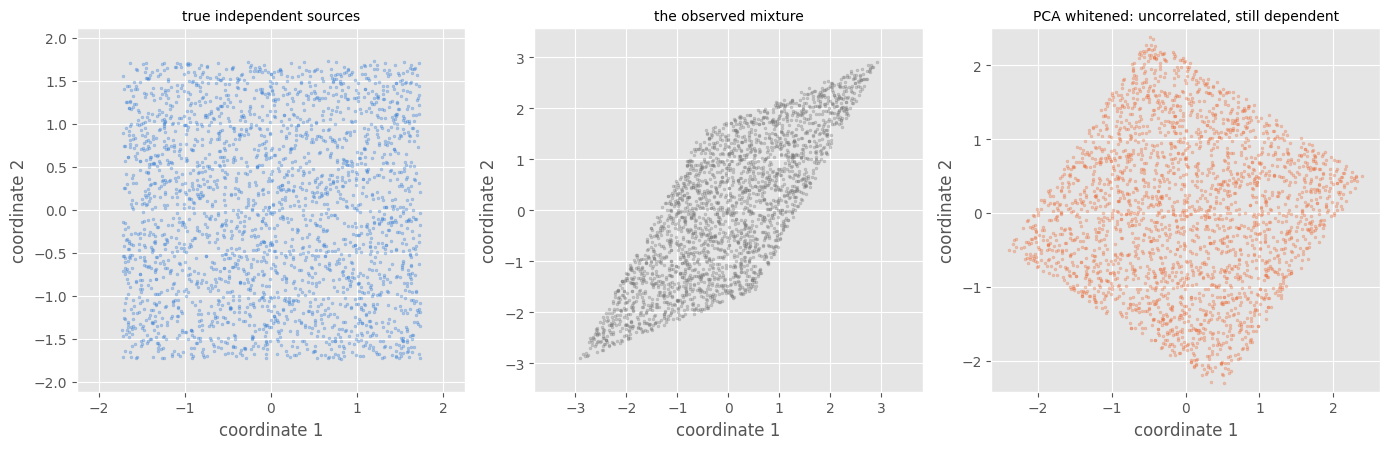

In [18]:
def mutual_information(a, b, bins=24):
    # histogram estimate of I(a; b) in nats
    H, _, _ = np.histogram2d(a, b, bins=bins)
    P = H / H.sum()
    pa = P.sum(axis=1, keepdims=True)
    pb = P.sum(axis=0, keepdims=True)
    nz = P > 0
    return float((P[nz] * np.log(P[nz] / (pa @ pb)[nz])).sum())


r_mix = np.random.default_rng(4)
S_src = r_mix.uniform(-1, 1, size=(20000, 2))
S_src = (S_src - S_src.mean(axis=0)) / S_src.std(axis=0)
A_mix = np.array([[1.0, 0.7], [0.4, 1.3]])
X_mix = S_src @ A_mix.T

pca_mix = Principal_Component_Analysis().fit(X_mix)
Z_mix = pca_mix.transform(X_mix)
Zw_mix = pca_mix.whiten(X_mix)

print('correlation between the two PCA scores           %.2e' % abs(np.corrcoef(Z_mix.T)[0, 1]))
print('covariance of the whitened scores, max |off - I| %.2e'
      % np.abs(np.cov(Zw_mix.T, ddof=1) - np.eye(2)).max())
print()
print('mutual information, true independent sources     %.5f nats' % mutual_information(S_src[:, 0], S_src[:, 1]))
print('mutual information, uncorrelated PCA scores      %.5f nats' % mutual_information(Z_mix[:, 0], Z_mix[:, 1]))
print()
print('correlation of the squares, true sources         %+.4f' % np.corrcoef((S_src ** 2).T)[0, 1])
print('correlation of the squares, PCA scores           %+.4f' % np.corrcoef((Z_mix ** 2).T)[0, 1])

fig, ax = plt.subplots(1, 3, figsize=(14, 4.6))
panels = [(S_src, 'true independent sources', blue),
          (X_mix, 'the observed mixture', '0.45'),
          (Zw_mix, 'PCA whitened: uncorrelated, still dependent', orange)]
for a, (Zp, title, col) in zip(ax, panels):
    a.scatter(Zp[:2500, 0], Zp[:2500, 1], s=4, alpha=0.3, color=col)
    a.set_title(title, fontsize=10)
    a.set_xlabel('coordinate 1'); a.set_ylabel('coordinate 2')
    a.set_aspect('equal', adjustable='datalim')

plt.tight_layout()
plt.show()

## Where PCA is commonly misread

**Variance is not information, and it is not class separation.** PCA maximises variance without reference to
any label, so a direction along which two classes are far apart but the total spread is small will be ranked
below a direction along which everything varies a lot for reasons that have nothing to do with the task. The
projection onto the first two components keeps 28.0% of the variance and drops the 1-NN label agreement from
0.9706 to 0.5418; sixteen components keep 84.8% and recover 0.9617. `classification/lda_qda.ipynb` maximises
between-class over within-class scatter instead and is the right tool when labels exist.

**PCA depends on the units.** The covariance matrix is not invariant to rescaling a feature, so multiplying one
column by 100 makes it dominate the leading component. On the digits all 64 features are pixels in the same
units, so working from the covariance matrix is the right choice. When features have different units — the
13 chemical measurements of `clustering/gmm.ipynb`, for example — the columns have to be standardised first,
which amounts to running PCA on the correlation matrix instead. The cell below shows how far the leading
component moves when a single pixel is amplified.

**It is linear.** The reconstruction is confined to an affine subspace. Data lying on a curved surface is
described badly by any flat approximation of it, however many components are used, and both other notebooks in
this folder relax linearity in different ways.

In [19]:
scaled = X_train.copy()
target_pixel = int(np.argmax(X_train.var(axis=0)))
scaled[:, target_pixel] *= 100.0

pca_scaled = Principal_Component_Analysis().fit(scaled)
angle_shift = np.degrees(np.arccos(np.clip(abs(pca_scaled.components[:, 0] @ V[:, 0]), -1, 1)))

print('amplifying pixel %d by 100:' % target_pixel)
print('  leading component moves %.2f degrees' % angle_shift)
print('  weight on that pixel in the new leading component: %.4f (was %.4f)'
      % (abs(pca_scaled.components[target_pixel, 0]), abs(V[target_pixel, 0])))
print('  variance it now explains: %.4f (was %.4f)'
      % (pca_scaled.explained_variance_ratio[0], evr[0]))
print()
print('variance kept and class structure kept, side by side:')
print('%6s %14s %26s' % ('k', 'variance kept', '1-NN label agreement'))
for k in [2, 4, 8, 16, 32, 64]:
    print('%6d %14.4f %26.4f'
          % (k, cumulative[k - 1], neighbour_agreement(pca.transform(X_test, k), y_test)))

amplifying pixel 42 by 100:
  leading component moves 69.39 degrees
  weight on that pixel in the new leading component: 0.9999 (was 0.3413)
  variance it now explains: 0.9974 (was 0.1450)

variance kept and class structure kept, side by side:
     k  variance kept       1-NN label agreement
     2         0.2800                     0.5418
     4         0.4817                     0.8007
     8         0.6714                     0.9422
    16         0.8483                     0.9617
    32         0.9651                     0.9715
    64         1.0000                     0.9706


## Summary

In [20]:
print('%-46s %s' % ('training images', '%d x %d pixels' % (N, D)))
print('%-46s %.4f' % ('total variance in the training set', lam.sum()))
print('%-46s %.4f' % ('variance in the first component', evr[0]))
print('%-46s %d' % ('components for 90% of the variance', needed[0.9]))
print('%-46s %d' % ('components for 95% of the variance', needed[0.95]))
print('%-46s %.2e' % ('max |Var(z_j) - lambda_j|', variance_gap))
print('%-46s %.2e' % ('max off-diagonal of Cov(Z)', cov_offdiag))
print('%-46s %.2e' % ('reconstruction error vs discarded spectrum', max(gaps)))
print('%-46s %.6f' % ('gradient descent J / PCA J at k = 8', J_ae / J_pca))
print('%-46s %.4f' % ('largest principal angle, GD vs PCA (deg)', principal_angles(W2.T, Vk).max()))
print()
print('total notebook runtime: %.1f s' % (time.time() - notebook_start))

training images                                4496 x 64 pixels
total variance in the training set             4.7002
variance in the first component                0.1450
components for 90% of the variance             21
components for 95% of the variance             29
max |Var(z_j) - lambda_j|                      1.33e-15
max off-diagonal of Cov(Z)                     1.44e-15
reconstruction error vs discarded spectrum     2.22e-15
gradient descent J / PCA J at k = 8            1.000005
largest principal angle, GD vs PCA (deg)       0.0032

total notebook runtime: 16.5 s


- PCA is defined twice over and the definitions coincide. Maximising $\mathbf{w}^\top\Sigma\mathbf{w}$ under
  $\lVert\mathbf{w}\rVert=1$ gives $\Sigma\mathbf{w}=\lambda\mathbf{w}$ with the projected variance equal to
  $\lambda$; minimising the rank-$k$ reconstruction error gives the same eigenvectors, because captured
  variance plus reconstruction error is a constant. Both were solved numerically here without an eigensolver —
  orthogonal iteration and plain gradient descent — and both landed on the fitted subspace, to 1.6e-05
  degrees and to 0.0032 degrees respectively.
- **Centring is part of the method.** Skipping it makes the leading direction point at the mean image, 0.387
  degrees away from it, claiming 69.85% of a quantity that is not variance, and costs 13.4% extra
  reconstruction error at $k = 2$.
- **The eigenvalues are the variances.** Measured against the fitted scores they agree to 1.3e-15, the score
  covariance is diagonal to 1.4e-15, and the reconstruction error equals the discarded tail of the spectrum to
  2.2e-15.
- **The spectrum decays gradually on this data.** No sharp elbow: 21 of 64 components are needed for 90% of the
  variance and 29 for 95%. The first two hold 28.0%, which is why the two-dimensional picture is crowded.
- **Use the SVD of the centred matrix.** Forming $\tilde{X}^\top\tilde{X}$ squares the condition number, and on
  a matrix with singular values spanning $10^9$ the eigenvalue route returns the smallest one 230% too large
  and its direction 2.0 degrees off, while the SVD stays accurate to 8.2e-09. On the digits the two agree, but
  the agreement is a property of this spectrum rather than of the method.
- **The axes are a convention, the subspace is the content.** The reconstruction objective is invariant to
  $W_1W_2 = (W_1A^{-1})(AW_2)$, so it fixes only the span. PCA's ordering by variance is what makes the
  individual components well defined, and `neural_networks/autoencoder.ipynb` shows a method that finds the
  same subspace while producing entirely different axes on it.
- **Uncorrelated is not independent.** The scores are uncorrelated by construction, to 8.7e-16 on the mixed-
  sources example, and still carry 0.257 nats of mutual information against the sources' 0.013. That gap is
  what `ica.ipynb` is about.

What PCA cannot do is find structure that is not a linear subspace, or order components by anything other than
variance, or separate mixed signals. The other two notebooks in this folder take those up.